In [35]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [36]:
DATA_PATH = Path(
    "../data/processed/audio_features.csv"
)

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(240, 44)


,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,...,mfcc_13_mean,mfcc_13_std,item,condition,method,process,score_mean,score_std,score_median,n_ratings
0,0.031402,0.035702,0.037500,0.034218,974.761973,543.516470,810.748935,232.394348,1804.392492,822.144230,...,2.051651,9.129880,DE_CosmosLandromat_remix1_LD6,LP3.5,DE,LP35,19.230769,11.772197,20.0,26
1,0.032454,0.035265,0.053428,0.059231,1602.597174,1083.385344,1473.561877,348.874161,2920.521860,1707.200039,...,-0.259503,9.164764,DE_CosmosLandromat_remix1_LD6,LP7,DE,LP70,44.153846,21.528943,40.5,26
2,0.034160,0.033339,0.066034,0.074404,2362.891636,1554.666661,2695.249999,731.598696,4242.365762,2712.605690,...,-2.673538,6.828379,DE_CosmosLandromat_remix1_LD6,Q1,DE,OpenUnmix_mid,18.346154,9.616412,16.0,26
3,0.034937,0.033483,0.058914,0.077742,2453.770404,1750.814452,3128.944566,920.300337,4623.068797,3333.164288,...,1.487528,7.693702,DE_CosmosLandromat_remix1_LD6,Q2,DE,TFC_TDF_U_Net_mid,26.769231,15.092535,22.0,26
4,0.029821,0.035545,0.055902,0.065832,2535.865324,1661.842621,3345.480041,958.711958,4767.331265,3343.154888,...,-3.328747,8.267073,DE_CosmosLandromat_remix1_LD6,Q3,DE,Cocktail_mid,42.576923,22.409236,39.0,26


In [37]:
feature_columns = [
    col for col in df.columns
    if col.startswith((
        "rms_",
        "zcr_",
        "centroid_",
        "bandwidth_",
        "rolloff_",
        "mfcc_"
    ))
]


print("Number of features:", len(feature_columns))

Number of features: 36


In [38]:
delta_df = df.copy()

reference_features = (
    df[df["process"] == "reference"]
    .set_index("item")[feature_columns]
)

print(reference_features.shape)

(30, 36)


In [39]:
delta_columns = []

for feature in feature_columns:

    delta_col = f"delta_{feature}"

    delta_df[delta_col] = (
        delta_df[feature]
        - delta_df["item"].map(
            reference_features[feature]
        )
    )

    delta_columns.append(delta_col)

In [40]:
print("Number of delta features:", len(delta_columns))

delta_df[
    [
        "item",
        "process",
        "score_mean",
        "delta_bandwidth_mean",
        "delta_centroid_mean",
        "delta_rolloff_mean"
    ]
].head(8)

Number of delta features: 36


,item,process,score_mean,delta_bandwidth_mean,delta_centroid_mean,delta_rolloff_mean
0,DE_CosmosLandromat_remix1_LD6,LP35,19.230769,-3294.411782,-2423.222116,-4820.389877
1,DE_CosmosLandromat_remix1_LD6,LP70,44.153846,-2631.598840,-1795.386915,-3704.260509
2,DE_CosmosLandromat_remix1_LD6,OpenUnmix_mid,18.346154,-1409.910718,-1035.092453,-2382.416607
3,DE_CosmosLandromat_remix1_LD6,TFC_TDF_U_Net_mid,26.769231,-976.216151,-944.213685,-2001.713573
4,DE_CosmosLandromat_remix1_LD6,Cocktail_mid,42.576923,-759.680676,-862.118765,-1857.451104
5,DE_CosmosLandromat_remix1_LD6,DeepFilterNet2_mid,53.192308,-808.509078,-543.433046,-1485.940899
6,DE_CosmosLandromat_remix1_LD6,PSM_quantize_mask,73.115385,-155.088609,-122.971326,-384.425131
7,DE_CosmosLandromat_remix1_LD6,reference,99.423077,0.000000,0.000000,0.000000


In [41]:
delta_df[delta_columns].isna().sum().sum()

np.int64(0)

In [42]:
X_delta = delta_df[delta_columns]

y_delta = delta_df["score_mean"]

groups_delta = delta_df["item"]

print(X_delta.shape)

(240, 36)


In [43]:
gkf_delta = GroupKFold(
    n_splits=5
)

In [44]:
delta_rf_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf_delta.split(
        X_delta,
        y_delta,
        groups_delta
    ),
    start=1
):

    X_train = X_delta.iloc[train_idx]
    X_test = X_delta.iloc[test_idx]

    y_train = y_delta.iloc[train_idx]
    y_test = y_delta.iloc[test_idx]

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    delta_rf_results.append({
        "fold": fold,
        "MAE": mean_absolute_error(
            y_test,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                y_pred
            )
        ),
        "R2": r2_score(
            y_test,
            y_pred
        )
    })

In [45]:
delta_rf_results_df = pd.DataFrame(
    delta_rf_results
)


delta_rf_results_df

,fold,MAE,RMSE,R2
0,1,10.423464,15.866839,0.679999
1,2,9.857528,14.796054,0.698302
2,3,11.469108,17.186074,0.619482
3,4,7.188389,10.379221,0.864548
4,5,11.325956,16.630344,0.653179


In [46]:
delta_rf_results_df[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

,MAE,RMSE,R2
mean,10.052889,14.971707,0.703102
std,1.732572,2.719262,0.095008


In [47]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.ensemble import RandomForestRegressor

In [48]:
param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 0.8, 1.0]
}

In [49]:
outer_cv = GroupKFold(n_splits=5)

tuned_results = []
best_params_per_fold = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_delta,
        y_delta,
        groups_delta
    ),
    start=1
):

    X_train = X_delta.iloc[train_idx]
    X_test = X_delta.iloc[test_idx]

    y_train = y_delta.iloc[train_idx]
    y_test = y_delta.iloc[test_idx]

    groups_train = groups_delta.iloc[train_idx]

    # Inner CV only on training groups
    inner_cv = GroupKFold(n_splits=4)

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_grid,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=inner_cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    tuned_results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    best_params_per_fold.append({
        "fold": fold,
        **search.best_params_
    })
    

In [50]:
tuned_results_df = pd.DataFrame(
    tuned_results
)

tuned_results_df


,fold,MAE,RMSE,R2
0,1,10.238628,15.329285,0.701314
1,2,8.792170,13.567538,0.746322
2,3,10.682876,15.808488,0.678040
3,4,7.685225,10.963646,0.848865
4,5,11.041579,15.753884,0.688773


In [51]:
tuned_results_df[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

,MAE,RMSE,R2
mean,9.688096,14.284568,0.732663
std,1.408791,2.068532,0.069968


In [52]:
best_params_df = pd.DataFrame(
    best_params_per_fold
)

best_params_df

,fold,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth
0,1,1000,2,2,sqrt,15
1,2,1000,2,2,sqrt,15
2,3,1000,2,2,sqrt,15
3,4,1000,2,2,sqrt,15
4,5,1000,2,2,sqrt,15


In [53]:
processed_df = delta_df[
    delta_df["process"] != "reference"
].copy()

X_processed = processed_df[delta_columns]
y_processed = processed_df["score_mean"]
groups_processed = processed_df["item"]

print(X_processed.shape)
print(groups_processed.nunique())

(210, 36)
30


In [54]:
outer_cv = GroupKFold(n_splits=5)

processed_tuned_results = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_processed,
        y_processed,
        groups_processed
    ),
    start=1
):

    X_train = X_processed.iloc[train_idx]
    X_test = X_processed.iloc[test_idx]

    y_train = y_processed.iloc[train_idx]
    y_test = y_processed.iloc[test_idx]

    groups_train = groups_processed.iloc[train_idx]

    inner_cv = GroupKFold(n_splits=4)

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_grid,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=inner_cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)

    processed_tuned_results.append({
        "fold": fold,
        "MAE": mean_absolute_error(
            y_test,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                y_pred
            )
        ),
        "R2": r2_score(
            y_test,
            y_pred
        )
    })

In [55]:
processed_results_df = pd.DataFrame(
    processed_tuned_results
)

processed_results_df

,fold,MAE,RMSE,R2
0,1,10.275154,15.153236,0.576307
1,2,9.737439,14.302372,0.587881
2,3,12.199831,18.236132,0.417360
3,4,8.685161,12.518068,0.730146
4,5,11.803598,15.790650,0.511038


In [56]:
processed_results_df[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

,MAE,RMSE,R2
mean,10.540236,15.200092,0.564546
std,1.458286,2.095689,0.114709


In [57]:
processed_absolute_df = df[
    df["process"] != "reference"
].copy()

X_abs_processed = processed_absolute_df[feature_columns]
y_abs_processed = processed_absolute_df["score_mean"]
groups_abs_processed = processed_absolute_df["item"]

print(X_abs_processed.shape)

(210, 36)


In [58]:
abs_tuned_results = []

outer_cv = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_abs_processed,
        y_abs_processed,
        groups_abs_processed
    ),
    start=1
):

    X_train = X_abs_processed.iloc[train_idx]
    X_test = X_abs_processed.iloc[test_idx]

    y_train = y_abs_processed.iloc[train_idx]
    y_test = y_abs_processed.iloc[test_idx]

    groups_train = groups_abs_processed.iloc[train_idx]

    inner_cv = GroupKFold(n_splits=4)

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_grid,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=inner_cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)

    abs_tuned_results.append({
        "fold": fold,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_test, y_pred)
        ),
        "R2": r2_score(y_test, y_pred)
    })

In [59]:
abs_processed_results_df = pd.DataFrame(
    abs_tuned_results
)

abs_processed_results_df

,fold,MAE,RMSE,R2
0,1,13.270003,18.154122,0.391878
1,2,11.864412,15.784535,0.498039
2,3,14.360108,19.092977,0.361322
3,4,14.052351,20.266135,0.292712
4,5,18.445031,25.953813,-0.320922


In [60]:
abs_processed_results_df[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

,MAE,RMSE,R2
mean,14.398381,19.850316,0.244605
std,2.459208,3.788363,0.324683


In [61]:
final_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=GroupKFold(n_splits=5),
    random_state=42,
    n_jobs=-1
)

final_search.fit(
    X_processed,
    y_processed,
    groups=groups_processed
)

final_model = final_search.best_estimator_

print(final_search.best_params_)

{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}


In [62]:
final_model.fit(
    X_processed,
    y_processed
)

,n_estimators,1000
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    final_model,
    MODEL_DIR / "reference_based_random_forest.joblib"
    
)

['..\\models\\reference_based_random_forest.joblib']

In [64]:
joblib.dump(
    delta_columns,
    MODEL_DIR / "delta_feature_names.joblib"
)

['..\\models\\delta_feature_names.joblib']

In [65]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

oof_predictions = np.zeros(len(X_processed))

outer_cv = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_processed,
        y_processed,
        groups_processed
    ),
    start=1
):

    X_train = X_processed.iloc[train_idx]
    X_test = X_processed.iloc[test_idx]

    y_train = y_processed.iloc[train_idx]

    groups_train = groups_processed.iloc[train_idx]

    inner_cv = GroupKFold(n_splits=4)

    search = RandomizedSearchCV(
        estimator=RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=param_grid,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=inner_cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    oof_predictions[test_idx] = (
        search.best_estimator_.predict(X_test)
    )

In [66]:
oof_mae = mean_absolute_error(
    y_processed,
    oof_predictions
)

oof_rmse = np.sqrt(
    mean_squared_error(
        y_processed,
        oof_predictions
    )
)

oof_r2 = r2_score(
    y_processed,
    oof_predictions
)

print("OOF MAE :", oof_mae)
print("OOF RMSE:", oof_rmse)
print("OOF R²  :", oof_r2)

OOF MAE : 10.540236485443991
OOF RMSE: 15.315231326722385
OOF R²  : 0.5690349414643581


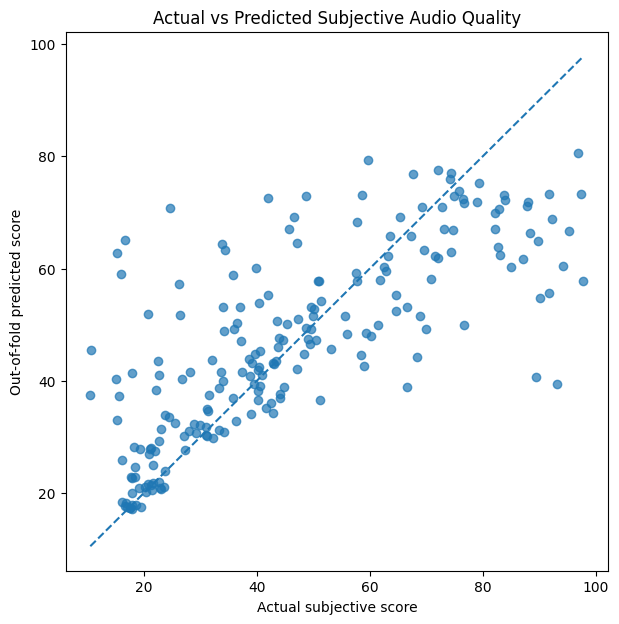

In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))

plt.scatter(
    y_processed,
    oof_predictions,
    alpha=0.7
)

min_score = min(
    y_processed.min(),
    oof_predictions.min()
)

max_score = max(
    y_processed.max(),
    oof_predictions.max()
)

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

plt.xlabel("Actual subjective score")
plt.ylabel("Out-of-fold predicted score")

plt.title(
    "Actual vs Predicted Subjective Audio Quality"
)

plt.show()

In [69]:
residuals = y_processed.to_numpy() - oof_predictions

print("Mean residual:", residuals.mean())
print("Residual std:", residuals.std())

Mean residual: -0.6665325379080093
Residual std: 15.300720406795513


In [70]:
oof_df = pd.DataFrame({
    "actual": y_processed.to_numpy(),
    "predicted": oof_predictions
})

oof_df["error"] = (
    oof_df["actual"] -
    oof_df["predicted"]
)

oof_df["abs_error"] = np.abs(
    oof_df["error"]
)

oof_df.sort_values(
    "abs_error",
    ascending=False
).head(10)

,actual,predicted,error,abs_error
160,93.192308,39.538150,53.654158,53.654158
159,89.384615,40.689067,48.695548,48.695548
177,16.769231,65.087318,-48.318087,48.318087
191,15.346154,62.859211,-47.513057,47.513057
163,24.615385,70.808734,-46.193349,46.193349
170,15.923077,58.996710,-43.073633,43.073633
97,97.807692,57.776107,40.031585,40.031585
117,91.692308,55.740225,35.952082,35.952082
209,90.192308,54.718112,35.474195,35.474195
107,10.692308,45.448321,-34.756013,34.756013


In [71]:
oof_df = processed_df[
    ["item", "method", "process", "score_mean"]
].reset_index(drop=True).copy()

oof_df["predicted"] = oof_predictions

oof_df["error"] = (
    oof_df["score_mean"]
    - oof_df["predicted"]
)

oof_df["abs_error"] = np.abs(
    oof_df["error"]
)

oof_df.sort_values(
    "abs_error",
    ascending=False
).head(15)

,item,method,process,score_mean,predicted,error,abs_error
160,TM_01b_trumpet,TM,TM10.5k,93.192308,39.538150,53.654158,53.654158
159,TM_01b_trumpet,TM,TM9k,89.384615,40.689067,48.695548,48.695548
177,TM_CreatureFromTheBlackjackTable,TM,TM3k,16.769231,65.087318,-48.318087,48.318087
191,UN_21_violin,UN,UN3k,15.346154,62.859211,-47.513057,47.513057
163,TM_02_violin,TM,TM3k,24.615385,70.808734,-46.193349,46.193349
170,TM_AmateurOnPurpose,TM,TM3k,15.923077,58.996710,-43.073633,43.073633
97,LP_CreatureFromTheBlackjackTable,LP,LP150,97.807692,57.776107,40.031585,40.031585
117,PE_AmateurOnPurpose,PE,PE_2048_MS_NMR16,91.692308,55.740225,35.952082,35.952082
209,UN_CreatureFromTheBlackjackTable,UN,UN10.5k,90.192308,54.718112,35.474195,35.474195
107,PE_39_clapping,PE,PE_4096_MS_NMR10,10.692308,45.448321,-34.756013,34.756013


In [72]:
method_errors = (
    oof_df
    .groupby("method")
    .agg(
        MAE=("abs_error", "mean"),
        n=("abs_error", "count")
    )
    .sort_values("MAE", ascending=False)
)

method_errors

,MAE,n
method,,
TM,17.158718,28
PE,13.165490,28
UN,12.595903,28
LP,11.216501,28
SH,9.863300,28
DE,6.020744,70


In [73]:
print(len(oof_predictions))
print(len(processed_df))

print(np.isnan(oof_predictions).sum())

210
210
0


In [74]:
enhanced_df = processed_df.copy()

abs_delta_columns = []

for col in delta_columns:

    new_col = f"abs_{col}"

    enhanced_df[new_col] = np.abs(
        enhanced_df[col]
    )

    abs_delta_columns.append(new_col)

In [75]:
enhanced_features = (
    delta_columns
    + abs_delta_columns
)

X_enhanced = enhanced_df[
    enhanced_features
]

y_enhanced = enhanced_df["score_mean"]
groups_enhanced = enhanced_df["item"]

print(X_enhanced.shape)

(210, 72)


In [76]:
enhanced_results = []
enhanced_oof_predictions = np.zeros(len(X_enhanced))

outer_cv = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_enhanced,
        y_enhanced,
        groups_enhanced
    ),
    start=1
):

    X_train = X_enhanced.iloc[train_idx]
    X_test = X_enhanced.iloc[test_idx]

    y_train = y_enhanced.iloc[train_idx]
    y_test = y_enhanced.iloc[test_idx]

    groups_train = groups_enhanced.iloc[train_idx]

    inner_cv = GroupKFold(n_splits=4)

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_grid,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=inner_cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)

    enhanced_oof_predictions[test_idx] = y_pred

    enhanced_results.append({
        "fold": fold,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_test, y_pred)
        ),
        "R2": r2_score(y_test, y_pred)
        
    })

In [77]:
enhanced_results_df = pd.DataFrame(
    enhanced_results
)

enhanced_results_df

,fold,MAE,RMSE,R2
0,1,9.113628,13.188791,0.679040
1,2,9.566070,14.040428,0.602838
2,3,11.408666,15.778910,0.563797
3,4,9.005808,12.507141,0.730617
4,5,10.909386,14.284096,0.599889


In [78]:
enhanced_results_df[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

,MAE,RMSE,R2
mean,10.000711,13.959873,0.635236
std,1.092439,1.237488,0.067858


In [79]:
enhanced_oof_df = enhanced_df[
    ["item", "method", "process", "score_mean"]
].reset_index(drop=True).copy()

enhanced_oof_df["predicted"] = (
    enhanced_oof_predictions
)

enhanced_oof_df["error"] = (
    enhanced_oof_df["score_mean"]
    - enhanced_oof_df["predicted"]
)

enhanced_oof_df["abs_error"] = np.abs(
    enhanced_oof_df["error"]
)

In [80]:
enhanced_oof_df.groupby(
    "method"
).agg(
    MAE=("abs_error", "mean"),
    n=("abs_error", "count")
).sort_values(
    "MAE",
    ascending=False
)


,MAE,n
method,,
TM,15.381655,28
UN,11.780986,28
LP,11.205840,28
PE,10.339695,28
SH,9.037627,28
DE,6.903813,70


In [81]:
enhanced_oof_df.sort_values(
    "abs_error",
    ascending=False
).head(15)

,item,method,process,score_mean,predicted,error,abs_error
177,TM_CreatureFromTheBlackjackTable,TM,TM3k,16.769231,61.053674,-44.284443,44.284443
163,TM_02_violin,TM,TM3k,24.615385,67.764646,-43.149261,43.149261
97,LP_CreatureFromTheBlackjackTable,LP,LP150,97.807692,55.697680,42.110012,42.110012
160,TM_01b_trumpet,TM,TM10.5k,93.192308,51.239977,41.952330,41.952330
209,UN_CreatureFromTheBlackjackTable,UN,UN10.5k,90.192308,48.647699,41.544608,41.544608
159,TM_01b_trumpet,TM,TM9k,89.384615,52.099937,37.284678,37.284678
90,LP_AmateurOnPurpose,LP,LP150,95.192308,60.037829,35.154479,35.154479
191,UN_21_violin,UN,UN3k,15.346154,50.178768,-34.832614,34.832614
178,TM_CreatureFromTheBlackjackTable,TM,TM5k,42.038462,73.704006,-31.665545,31.665545
170,TM_AmateurOnPurpose,TM,TM3k,15.923077,47.565678,-31.642601,31.642601


In [82]:
final_enhanced_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=GroupKFold(n_splits=5),
    random_state=42,
    n_jobs=-1
)

final_enhanced_search.fit(
    X_enhanced,
    y_enhanced,
    groups=groups_enhanced
)

final_enhanced_model = (
    final_enhanced_search.best_estimator_
)

print(
    final_enhanced_search.best_params_
)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 5}


In [84]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    final_enhanced_model,
    MODEL_DIR /
    "final_reference_based_rf.joblib"
)

joblib.dump(
    enhanced_features,
    MODEL_DIR /
    "final_feature_names.joblib"
)

['..\\models\\final_feature_names.joblib']